## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [44]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

## Loading the dataset

In [4]:
df = pd.read_csv('Breast_Cancer.csv')

In [7]:
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
175,872113,B,8.671,14.45,54.42,227.2,0.09138,0.04276,0.00000,0.000000,...,17.04,58.36,259.2,0.1162,0.07057,0.00000,0.00000,0.2592,0.07848,NaN
338,897880,B,10.050,17.53,64.41,310.8,0.10070,0.07326,0.02511,0.017750,...,26.84,71.98,384.0,0.1402,0.14020,0.10550,0.06499,0.2894,0.07664,NaN
4,84358402,M,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.104300,...,16.67,152.20,1575.0,0.1374,0.20500,0.40000,0.16250,0.2364,0.07678,NaN
546,922577,B,10.320,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,...,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399,NaN
374,9013005,B,13.690,16.07,87.84,579.1,0.08302,0.06374,0.02556,0.020310,...,20.21,99.16,670.6,0.1105,0.20960,0.13460,0.06987,0.3323,0.07701,NaN
222,8812844,B,10.180,17.53,65.12,313.1,0.10610,0.08502,0.01768,0.019150,...,22.84,71.94,375.6,0.1406,0.14400,0.06572,0.05575,0.3055,0.08797,NaN
182,873701,M,15.700,20.31,101.20,766.6,0.09597,0.08799,0.06593,0.051890,...,32.82,129.30,1269.0,0.1414,0.35470,0.29020,0.15410,0.3437,0.08631,NaN
551,923780,B,11.130,22.44,71.49,378.4,0.09566,0.08194,0.04824,0.022570,...,28.26,77.80,436.6,0.1087,0.17820,0.15640,0.06413,0.3169,0.08032,NaN
499,91485,M,20.590,21.24,137.80,1320.0,0.10850,0.16440,0.21880,0.112100,...,30.76,163.20,1760.0,0.1464,0.35970,0.51790,0.21130,0.2480,0.08999,NaN
103,862980,B,9.876,19.40,63.95,298.3,0.10050,0.09697,0.06154,0.030290,...,26.83,72.22,361.2,0.1559,0.23020,0.26440,0.09749,0.2622,0.08490,NaN


In [8]:
df.shape

(569, 33)

In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [11]:
# BASIC DATA CLEANING
df = df.drop(columns=['id','Unnamed: 32'])

In [12]:
df.shape

(569, 31)

In [14]:
# Defining the input (X) and output (y)
# diagnosis is the target/output column

# M = Malignant
# B = Benign

X = df.drop('diagnosis', axis = 1)
y = df['diagnosis']

In [15]:
# CONVERT TARGET LABELS INTO NUMBERS
y = y.map({'M':1,'B':0})

In [16]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [17]:
print(y.value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [18]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (455, 30)
Testing data shape: (114, 30)


In [28]:
# FEATURE SCALING

# KNN is distance-based.
# Therefore, features must be brought onto
# comparable scales.

# IMPORTANT:
# fit_transform -> TRAINING DATA
# transform     -> TEST DATA

# We DO NOT fit the scaler on X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Now, Create the model

knn = KNeighborsClassifier(n_neighbors=5)

In [30]:
# Train the model
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [31]:
# Make predictions
y_pred =  knn.predict(X_test_scaled)

In [32]:
# Evaluate the model
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

In [33]:
# Showing the model prediction
print("MODEL PERFORMANCE")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

MODEL PERFORMANCE
Accuracy : 0.956140350877193
Precision: 0.9743589743589743
Recall   : 0.9047619047619048
F1 Score : 0.9382716049382716


In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print('Confusion Matrix')
print(cm)

Confusion Matrix
[[71  1]
 [ 4 38]]


In [39]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [42]:
# Finding the best value for K using Cross Validation
k_values = range(1,16)
k_values

range(1, 16)

In [53]:
cv_accuracy =[]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring='accuracy')
    cv_accuracy.append(scores.mean())


print("K vs CROSS-VALIDATION ACCURACY")

for k, score in zip(k_values,cv_accuracy):
    print(f'K = {k:02d}' ' - ' f'Accuracy = {score:.4f}')

K vs CROSS-VALIDATION ACCURACY
K = 01 - Accuracy = 0.9473
K = 02 - Accuracy = 0.9560
K = 03 - Accuracy = 0.9692
K = 04 - Accuracy = 0.9604
K = 05 - Accuracy = 0.9626
K = 06 - Accuracy = 0.9582
K = 07 - Accuracy = 0.9692
K = 08 - Accuracy = 0.9626
K = 09 - Accuracy = 0.9648
K = 10 - Accuracy = 0.9604
K = 11 - Accuracy = 0.9582
K = 12 - Accuracy = 0.9582
K = 13 - Accuracy = 0.9582
K = 14 - Accuracy = 0.9560
K = 15 - Accuracy = 0.9604


In [55]:
# Find the best value of K

best_index = np.argmax(cv_accuracy)
best_k = list(k_values)[best_index]
best_accuracy = cv_accuracy[best_index]

print("\nBest K:", best_k)
print("Best CV Accuracy:", best_accuracy)


Best K: 3
Best CV Accuracy: 0.9692307692307693


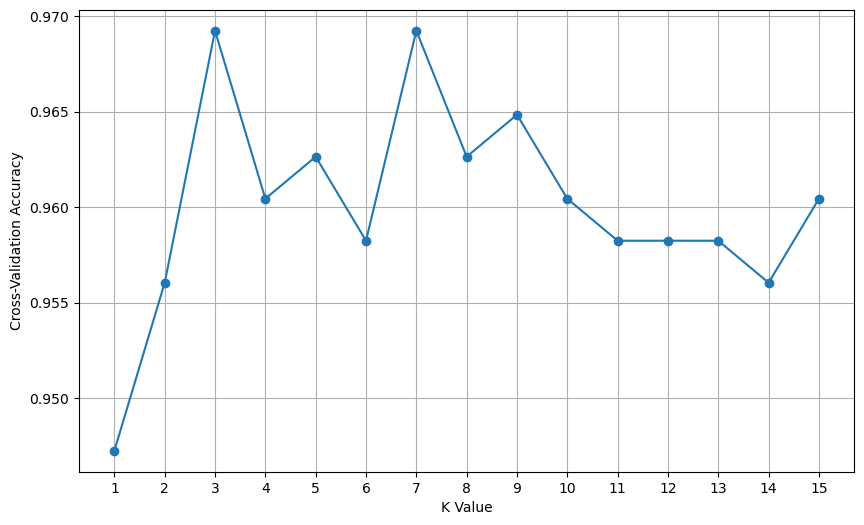

In [60]:
# Plotting K vs Accuracy

plt.figure(figsize=(10,6))
plt.plot(k_values, cv_accuracy, marker='o')

plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')

plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [61]:
# Now train the final model using the best K value
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [62]:
# Final Predictions
final_predictions = final_knn.predict(X_test_scaled)

In [67]:
# Final Model Evaluation
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)

print('Final Model Evaluation Results')
print(f"Best K   : {best_k}")
print(f"Accuracy : {final_accuracy*100:.2f}%")
print(f"Precision: {final_precision*100:.2f}%")
print(f"Recall   : {final_recall*100:.2f}%")
print(f"F1 Score : {final_f1*100:.2f}%")

Final Model Evaluation Results
Best K   : 3
Accuracy : 93.86%
Precision: 97.30%
Recall   : 85.71%
F1 Score : 91.14%


In [68]:
# Final Confusion Matrix
final_cm = confusion_matrix(y_test,final_predictions)
final_cm

array([[71,  1],
       [ 6, 36]])